In [9]:
import h5py
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
import os
from pathlib import Path
import pyfftw

import bacco

import sys
sys.path.append('/dipc/kstoreyf/muchisimocks/code')
import plotter
import utils
import data_loader
import generate_params as genp

%load_ext autoreload
%autoreload 2

In [ ]:
param_names_key = ['omega_cold', 'sigma8_cold', 'b1']
param_names_key_rp = ['omega_cold', 'sigma8_cold', 'sigma8_cold_x_b1']
param_names_bias = ['b2', 'bs2', 'bl']
param_names_bias_rp = ['sigma8_cold_sq_x_b2', 'sigma8_cold_sq_x_bs2', 'sigma8_cold_x_bl']
param_names_noise_rp = ['An_homog', 'sigma8_cold_x_An_b1', 'sigma8_cold_sq_x_An_b2', 'sigma8_cold_sq_x_An_bs2', 'sigma8_cold_x_An_bl']

In [12]:
color_pk = '#54afd6'
color_bispec = "#e14e4e"
color_pk_bispec = '#b0198f'
color_pgm = '#d18b13'
color_pk_pgm = '#327a3c'
color_pk_bispec_pgm = '#5e2e1f'

# inference: noiseless

In [ ]:
data_mode = 'muchisimocks'
tag_params = '_p5_n10000'
tag_biasparams = '_biasnest_p4_n320000'
bx = 1
tag_noise = None
tag_Anoise = None
tag_reparam = '_rp'
n_train = 10000

tag_num = f'_bx{bx}_ntrain{n_train}'
#statistics_arr = [['pk'], ['bispec'], ['pgm'], ['pk', 'bispec'], ['pk', 'pgm'], ['pk', 'bispec', 'pgm']]
statistics_arr = [['pk'], ['pk', 'pgm']]
tag_stats_arr = [f'_{"_".join(statistics)}' for statistics in statistics_arr]

# muchisimocks_pk_p5_n10000_biaszen_p4_n10000_ntrain10000
if tag_noise is None:
    tags_inf = [f'_{data_mode}{tag_stats}{tag_params}{tag_biasparams}{tag_reparam}{tag_num}' for tag_stats in tag_stats_arr]
else:
    tags_inf = [f'_{data_mode}{tag_stats}{tag_params}{tag_biasparams}{tag_noise}{tag_Anoise}{tag_reparam}{tag_num}' for tag_stats in tag_stats_arr]
    
inf_methods = ['sbi']*len(tags_inf)
labels = [utils.get_stat_label(stat) for stat in statistics_arr]
colors = [color_pk, color_bispec, color_pgm, color_pk_bispec, color_pk_pgm, color_pk_bispec_pgm]

In [4]:
# load training set parameters 
params_df, param_dict_fixed, biasparams_df, biasparams_dict_fixed, Anoise_df, Anoise_dict_fixed, random_ints, random_ints_bias = data_loader.load_params(tag_params, tag_biasparams, tag_Anoise=tag_Anoise)

# for muchisimocks, we will probably want to vary the same params as the training data
cosmo_param_names_vary, bias_param_names_vary, noise_param_names_vary = [], [], []
if params_df is not None:
    cosmo_param_names_vary = params_df.columns.tolist()
# TODO should this be test or train?
if biasparams_df is not None:
    bias_param_names_vary = biasparams_df.columns.tolist()
    bias_param_names_vary.remove('nest_layer')
    bias_param_names_vary.remove('idx_cosmo')
if Anoise_df is not None:
    noise_param_names_vary = Anoise_df.columns.tolist()
param_names_vary = cosmo_param_names_vary + bias_param_names_vary + noise_param_names_vary
print(param_names_vary)
param_labels = [utils.param_label_dict[param_name] for param_name in param_names_vary]


['omega_cold', 'sigma8_cold', 'hubble', 'omega_baryon', 'ns', 'b1', 'b2', 'bs2', 'bl']


In [5]:
# load fixed-cosmo test set
tag_params_test_fixed = '_shame_p0_n1000'
tag_biasparams_test_fixed = '_biasshame_p0_n1'
tag_noise_fixed = None
tag_Anoise_fixed = None
theta_test_fixed = data_loader.load_theta_test(tag_params_test_fixed, tag_biasparams_test_fixed, 
                                               tag_Anoise_test=tag_Anoise_fixed,
                                cosmo_param_names_vary=cosmo_param_names_vary, bias_param_names_vary=bias_param_names_vary,
                                noise_param_names_vary=noise_param_names_vary)
print(theta_test_fixed)

# get bounds (updated generate_params API)
dict_bounds_cosmo = genp.get_bounds('cosmo')
dict_bounds_bias = genp.get_bounds('bias')
extents = {**dict_bounds_cosmo, **dict_bounds_bias}


[ 0.3089      0.8159      0.6774      0.0486      0.9667      0.47410742
  0.12701492 -0.33881766 -0.82443643]


['omega_cold', 'sigma8_cold', 'hubble', 'omega_baryon', 'ns', 'b1', 'b2', 'bs2', 'bl']
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx1_ntrain10000/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx1_ntrain10000/samples_test_muchisimocks_pk_pgm_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy


Parameter sigma8_cold_sq_x_b2 in chain $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$ is not constrained


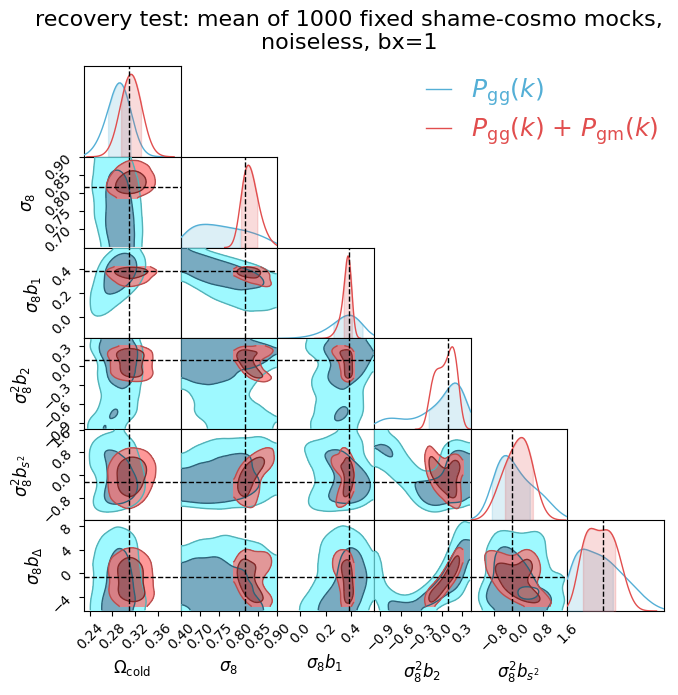

In [6]:
print(param_names_vary)
idx_obs = 0
title = f'recovery test: mean of 1000 fixed shame-cosmo mocks,\nnoiseless, bx=1'
tags_stats = [f'_{"_".join(statistics)}' for statistics in statistics_arr]
if tag_noise_fixed is None:
    tags_test = ['_'+data_mode + tag_stats + tag_params_test_fixed + tag_biasparams_test_fixed + '_mean' for tag_stats in tag_stats_arr]
else:
    tags_test = ['_'+data_mode + tag_stats + tag_params_test_fixed + tag_biasparams_test_fixed + tag_noise_fixed + tag_Anoise_fixed + '_mean' for tag_stats in tag_stats_arr]

#tags_test = [f'{tag_data_test_fixed}_mean']*len(tags_inf)
# doing utils.biasparam_names_ordered here instead of bias_param_names_vary in case some param sets don't vary all the bias params but we want to show them on the same plot
param_names_contour = ['omega_cold', 'sigma8_cold'] + bias_param_names_vary
#param_names_contour = ['omega_cold', 'sigma8_cold']
theta_test_show = theta_test_fixed[[i for i, name in enumerate(param_names_vary) if name in param_names_contour]]

plotter.plot_contours_inf(param_names_contour, idx_obs, theta_test_show, 
                        inf_methods, tags_inf, tags_test=tags_test,
                        colors=colors, labels=labels,
                        title=title, extents=extents)

# inference: noiseless

In [7]:
data_mode = 'muchisimocks'
tag_params = '_p5_n10000'
tag_biasparams = '_biasnest_p4_n320000'
bx = 4
tag_noise = None
tag_Anoise = None
tag_reparam = '_rp'
n_train = 10000

tag_num = f'_bx{bx}_ntrain{n_train}'
#statistics_arr = [['pk'], ['bispec'], ['pgm'], ['pk', 'bispec'], ['pk', 'pgm'], ['pk', 'bispec', 'pgm']]
statistics_arr = [['pk'], ['pk', 'pgm']]
tag_stats_arr = [f'_{"_".join(statistics)}' for statistics in statistics_arr]

# muchisimocks_pk_p5_n10000_biaszen_p4_n10000_ntrain10000
if tag_noise is None:
    tags_inf = [f'_{data_mode}{tag_stats}{tag_params}{tag_biasparams}{tag_reparam}{tag_num}' for tag_stats in tag_stats_arr]
else:
    tags_inf = [f'_{data_mode}{tag_stats}{tag_params}{tag_biasparams}{tag_noise}{tag_Anoise}{tag_reparam}{tag_num}' for tag_stats in tag_stats_arr]
    
inf_methods = ['sbi']*len(tags_inf)
labels = [utils.get_stat_label(stat) for stat in statistics_arr]
color_pk = '#54afd6'
color_bispec = "#e14e4e"
color_pk_bispec = '#b0198f'
color_pgm = '#d18b13'
color_pk_pgm = '#327a3c'
color_pk_bispec_pgm = '#5e2e1f'
colors = [color_pk, color_bispec, color_pgm, color_pk_bispec, color_pk_pgm, color_pk_bispec_pgm]

In [8]:
# load training set parameters 
params_df, param_dict_fixed, biasparams_df, biasparams_dict_fixed, Anoise_df, Anoise_dict_fixed, random_ints, random_ints_bias = data_loader.load_params(tag_params, tag_biasparams, tag_Anoise=tag_Anoise)

# for muchisimocks, we will probably want to vary the same params as the training data
cosmo_param_names_vary, bias_param_names_vary, noise_param_names_vary = [], [], []
if params_df is not None:
    cosmo_param_names_vary = params_df.columns.tolist()
# TODO should this be test or train?
if biasparams_df is not None:
    bias_param_names_vary = biasparams_df.columns.tolist()
    bias_param_names_vary.remove('nest_layer')
    bias_param_names_vary.remove('idx_cosmo')
if Anoise_df is not None:
    noise_param_names_vary = Anoise_df.columns.tolist()
param_names_vary = cosmo_param_names_vary + bias_param_names_vary + noise_param_names_vary
print(param_names_vary)
param_labels = [utils.param_label_dict[param_name] for param_name in param_names_vary]


['omega_cold', 'sigma8_cold', 'hubble', 'omega_baryon', 'ns', 'b1', 'b2', 'bs2', 'bl']


In [9]:
# load fixed-cosmo test set
tag_params_test_fixed = '_shame_p0_n1000'
tag_biasparams_test_fixed = '_biasshame_p0_n1'
tag_noise_fixed = None
tag_Anoise_fixed = None
theta_test_fixed = data_loader.load_theta_test(tag_params_test_fixed, tag_biasparams_test_fixed, 
                                               tag_Anoise_test=tag_Anoise_fixed,
                                cosmo_param_names_vary=cosmo_param_names_vary, bias_param_names_vary=bias_param_names_vary,
                                noise_param_names_vary=noise_param_names_vary)
print(theta_test_fixed)

# get bounds (updated generate_params API)
dict_bounds_cosmo = genp.get_bounds('cosmo')
dict_bounds_bias = genp.get_bounds('bias')
extents = {**dict_bounds_cosmo, **dict_bounds_bias}


[ 0.3089      0.8159      0.6774      0.0486      0.9667      0.47410742
  0.12701492 -0.33881766 -0.82443643]


['omega_cold', 'sigma8_cold', 'hubble', 'omega_baryon', 'ns', 'b1', 'b2', 'bs2', 'bl']
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx4_ntrain10000/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx4_ntrain10000/samples_test_muchisimocks_pk_pgm_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy


Parameter sigma8_cold_sq_x_b2 in chain $P_\mathrm{gg}(k)$ is not constrained
Parameter sigma8_cold_x_bl in chain $P_\mathrm{gg}(k)$ is not constrained


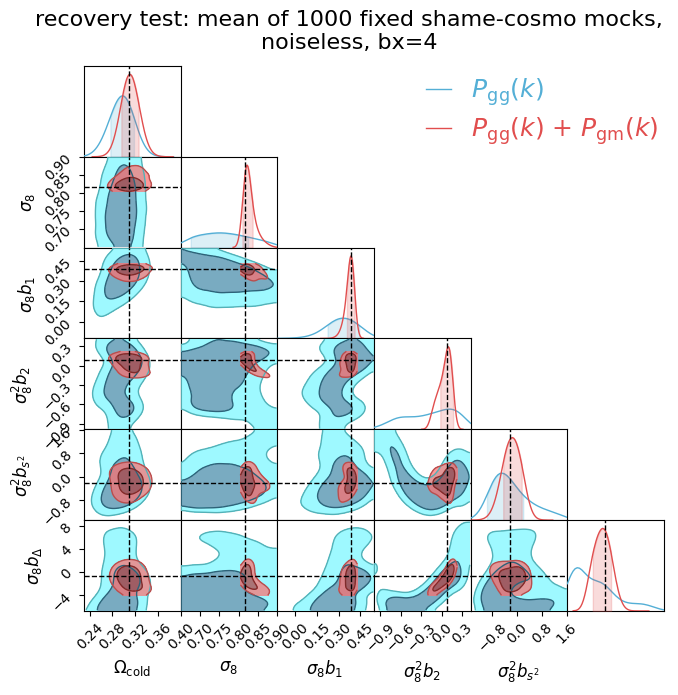

In [10]:
print(param_names_vary)
idx_obs = 0
title = f'recovery test: mean of 1000 fixed shame-cosmo mocks,\nnoiseless, bx=4'
tags_stats = [f'_{"_".join(statistics)}' for statistics in statistics_arr]
if tag_noise_fixed is None:
    tags_test = ['_'+data_mode + tag_stats + tag_params_test_fixed + tag_biasparams_test_fixed + '_mean' for tag_stats in tag_stats_arr]
else:
    tags_test = ['_'+data_mode + tag_stats + tag_params_test_fixed + tag_biasparams_test_fixed + tag_noise_fixed + tag_Anoise_fixed + '_mean' for tag_stats in tag_stats_arr]

#tags_test = [f'{tag_data_test_fixed}_mean']*len(tags_inf)
# doing utils.biasparam_names_ordered here instead of bias_param_names_vary in case some param sets don't vary all the bias params but we want to show them on the same plot
param_names_contour = ['omega_cold', 'sigma8_cold'] + bias_param_names_vary
#param_names_contour = ['omega_cold', 'sigma8_cold']
theta_test_show = theta_test_fixed[[i for i, name in enumerate(param_names_vary) if name in param_names_contour]]

plotter.plot_contours_inf(param_names_contour, idx_obs, theta_test_show, 
                        inf_methods, tags_inf, tags_test=tags_test,
                        colors=colors, labels=labels,
                        title=title, extents=extents)

## bx=32

In [11]:
data_mode = 'muchisimocks'
tag_params = '_p5_n10000'
tag_biasparams = '_biasnest_p4_n320000'
bx = 32
tag_noise = None
tag_Anoise = None
tag_reparam = '_rp'
n_train = 10000

tag_num = f'_bx{bx}_ntrain{n_train}'
#statistics_arr = [['pk'], ['bispec'], ['pgm'], ['pk', 'bispec'], ['pk', 'pgm'], ['pk', 'bispec', 'pgm']]
statistics_arr = [['pk']]
tag_stats_arr = [f'_{"_".join(statistics)}' for statistics in statistics_arr]

# muchisimocks_pk_p5_n10000_biaszen_p4_n10000_ntrain10000
if tag_noise is None:
    tags_inf = [f'_{data_mode}{tag_stats}{tag_params}{tag_biasparams}{tag_reparam}{tag_num}' for tag_stats in tag_stats_arr]
else:
    tags_inf = [f'_{data_mode}{tag_stats}{tag_params}{tag_biasparams}{tag_noise}{tag_Anoise}{tag_reparam}{tag_num}' for tag_stats in tag_stats_arr]
    
inf_methods = ['sbi']*len(tags_inf)
labels = [utils.get_stat_label(stat) for stat in statistics_arr]
color_pk = '#54afd6'
color_bispec = "#e14e4e"
color_pk_bispec = '#b0198f'
color_pgm = '#d18b13'
color_pk_pgm = '#327a3c'
color_pk_bispec_pgm = '#5e2e1f'
colors = [color_pk, color_bispec, color_pgm, color_pk_bispec, color_pk_pgm, color_pk_bispec_pgm]

In [12]:
# load training set parameters 
params_df, param_dict_fixed, biasparams_df, biasparams_dict_fixed, Anoise_df, Anoise_dict_fixed, random_ints, random_ints_bias = data_loader.load_params(tag_params, tag_biasparams, tag_Anoise=tag_Anoise)

# for muchisimocks, we will probably want to vary the same params as the training data
cosmo_param_names_vary, bias_param_names_vary, noise_param_names_vary = [], [], []
if params_df is not None:
    cosmo_param_names_vary = params_df.columns.tolist()
# TODO should this be test or train?
if biasparams_df is not None:
    bias_param_names_vary = biasparams_df.columns.tolist()
    bias_param_names_vary.remove('nest_layer')
    bias_param_names_vary.remove('idx_cosmo')
if Anoise_df is not None:
    noise_param_names_vary = Anoise_df.columns.tolist()
param_names_vary = cosmo_param_names_vary + bias_param_names_vary + noise_param_names_vary
print(param_names_vary)
param_labels = [utils.param_label_dict[param_name] for param_name in param_names_vary]


['omega_cold', 'sigma8_cold', 'hubble', 'omega_baryon', 'ns', 'b1', 'b2', 'bs2', 'bl']


In [13]:
# load fixed-cosmo test set
tag_params_test_fixed = '_shame_p0_n1000'
tag_biasparams_test_fixed = '_biasshame_p0_n1'
tag_noise_fixed = None
tag_Anoise_fixed = None
theta_test_fixed = data_loader.load_theta_test(tag_params_test_fixed, tag_biasparams_test_fixed, 
                                               tag_Anoise_test=tag_Anoise_fixed,
                                cosmo_param_names_vary=cosmo_param_names_vary, bias_param_names_vary=bias_param_names_vary,
                                noise_param_names_vary=noise_param_names_vary)
print(theta_test_fixed)

# get bounds (updated generate_params API)
dict_bounds_cosmo = genp.get_bounds('cosmo')
dict_bounds_bias = genp.get_bounds('bias')
extents = {**dict_bounds_cosmo, **dict_bounds_bias}


[ 0.3089      0.8159      0.6774      0.0486      0.9667      0.47410742
  0.12701492 -0.33881766 -0.82443643]


['omega_cold', 'sigma8_cold', 'hubble', 'omega_baryon', 'ns', 'b1', 'b2', 'bs2', 'bl']
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx32_ntrain10000/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_p0_n1_mean_pred.npy


Parameter sigma8_cold_x_bl in chain $P_\mathrm{gg}(k)$ is not constrained


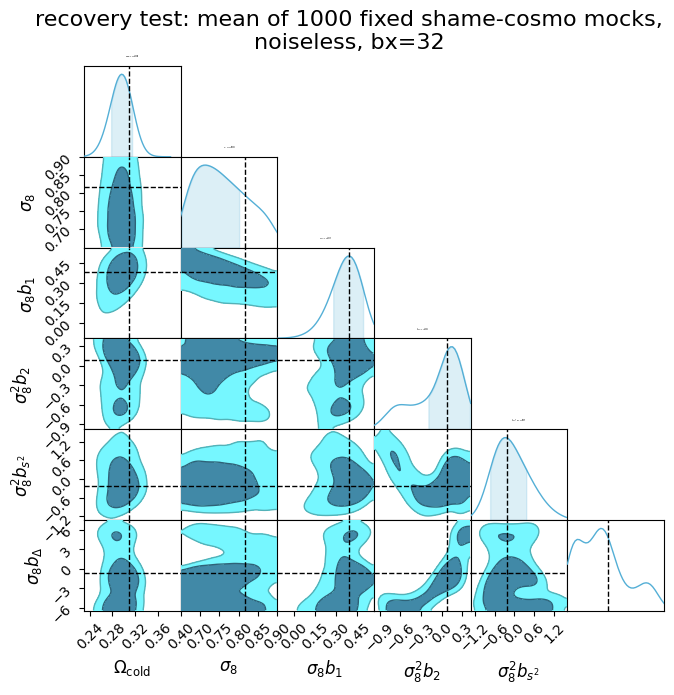

In [14]:
print(param_names_vary)
idx_obs = 0
title = f'recovery test: mean of 1000 fixed shame-cosmo mocks,\nnoiseless, bx=32'
tags_stats = [f'_{"_".join(statistics)}' for statistics in statistics_arr]
if tag_noise_fixed is None:
    tags_test = ['_'+data_mode + tag_stats + tag_params_test_fixed + tag_biasparams_test_fixed + '_mean' for tag_stats in tag_stats_arr]
else:
    tags_test = ['_'+data_mode + tag_stats + tag_params_test_fixed + tag_biasparams_test_fixed + tag_noise_fixed + tag_Anoise_fixed + '_mean' for tag_stats in tag_stats_arr]

#tags_test = [f'{tag_data_test_fixed}_mean']*len(tags_inf)
# doing utils.biasparam_names_ordered here instead of bias_param_names_vary in case some param sets don't vary all the bias params but we want to show them on the same plot
param_names_contour = ['omega_cold', 'sigma8_cold'] + bias_param_names_vary
#param_names_contour = ['omega_cold', 'sigma8_cold']
theta_test_show = theta_test_fixed[[i for i, name in enumerate(param_names_vary) if name in param_names_contour]]

plotter.plot_contours_inf(param_names_contour, idx_obs, theta_test_show, 
                        inf_methods, tags_inf, tags_test=tags_test,
                        colors=colors, labels=labels,
                        title=title, extents=extents)

## Results on the SHAMe mock

OOD SHAMe mock results using `data_mode_test='shame'` and `tag_mock='_nbar0.00022'`, for **P(k)** and **P(k)+PGM** at **bx=1** and **bx=4**.

## noiseless

### bx=1

In [41]:
# SHAMe mock results: bx=1 (pk and pk+pgm)
data_mode = 'muchisimocks'
tag_params = '_p5_n10000'
tag_biasparams = '_biasnest_p4_n320000'
tag_noise = ""
bx = 1
tag_reparam = '_rp'
n_train = 10000
statistics_arr = [['pk'], ['pk', 'pgm']]
tag_stats_arr = [f'_{"_".join(statistics)}' for statistics in statistics_arr]
tag_num = f'_bx{bx}_ntrain{n_train}'
tags_inf = [f'_{data_mode}{tag_stats}{tag_params}{tag_biasparams}{tag_noise}{tag_reparam}{tag_num}' for tag_stats in tag_stats_arr]
inf_methods = ['sbi'] * len(tags_inf)
labels = [utils.get_stat_label(stat) for stat in statistics_arr]
colors = [color_pk, color_pk_pgm]
print(tags_inf)

['_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx1_ntrain10000', '_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx1_ntrain10000']


In [42]:
# load training set parameters (no Anoise)
params_df, param_dict_fixed, biasparams_df, biasparams_dict_fixed, random_ints, random_ints_bias = data_loader.load_params(tag_params, tag_biasparams)
cosmo_param_names_vary, bias_param_names_vary = [], []
if params_df is not None:
    cosmo_param_names_vary = params_df.columns.tolist()
if biasparams_df is not None:
    bias_param_names_vary = biasparams_df.columns.tolist()
    bias_param_names_vary.remove('nest_layer')
    bias_param_names_vary.remove('idx_cosmo')
param_names_vary = cosmo_param_names_vary + bias_param_names_vary

# load SHAMe mock OOD test set
data_mode_test = 'shame'
tag_mock = '_nbar0.00022'
theta_test = data_loader.load_theta_ood(
    data_mode_test, tag_mock,
    cosmo_param_names_vary=cosmo_param_names_vary,
    bias_param_names_vary=bias_param_names_vary,
)
print(theta_test)

# get bounds (updated generate_params API)
dict_bounds_cosmo = genp.get_bounds('cosmo')
dict_bounds_bias = genp.get_bounds('bias')
extents = {**dict_bounds_cosmo, **dict_bounds_bias}

print(param_names_vary)

[ 0.3089      0.81590003  0.6774      0.0486      0.9667      0.47410742
  0.12701492 -0.33881766 -0.82443643]
['omega_cold', 'sigma8_cold', 'hubble', 'omega_baryon', 'ns', 'b1', 'b2', 'bs2', 'bl']


fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnest_p4_n320000_rp_bx1_ntrain10000/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnest_p4_n320000_rp_bx1_ntrain10000/samples_test_shame_pk_pgm_nbar0.00022_pred.npy


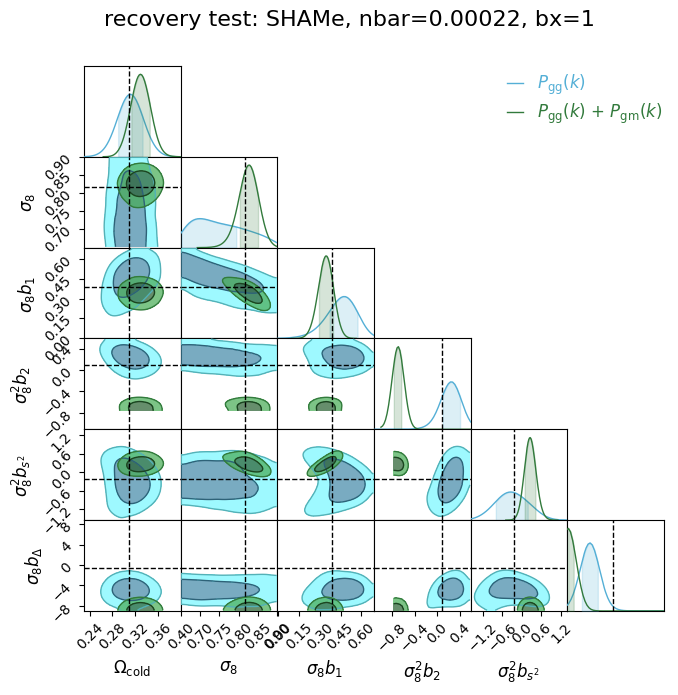

In [43]:
idx_obs = 0
title = f'recovery test: SHAMe, nbar={tag_mock.split("nbar")[-1]}, bx={bx}'
tags_test = ['_' + data_mode_test + tag_stats_arr[i] + tag_mock for i in range(len(tag_stats_arr))]

param_names_contour = ['omega_cold', 'sigma8_cold'] + utils.biasparam_names_ordered
theta_test_show = theta_test[[i for i, name in enumerate(param_names_vary) if name in param_names_contour]]

plotter.plot_contours_inf(
    param_names_contour, idx_obs, theta_test_show,
    inf_methods, tags_inf, tags_test=tags_test,
    colors=colors, labels=labels,
    title=title, extents=extents, fontsize_legend=12,
)

## noisy

### bx=1

In [20]:
# SHAMe mock results: bx=1 (pk and pk+pgm)
data_mode = 'muchisimocks'
tag_params = '_p5_n10000'
tag_biasparams = '_biasnoisenest_p9_n320000'
tag_noise = '_noise_unit_p5_n10000'
bx = 1
tag_reparam = '_rp'
n_train = 10000
statistics_arr = [['pk'], ['pk', 'pgm']]
tag_stats_arr = [f'_{"_".join(statistics)}' for statistics in statistics_arr]
tag_num = f'_bx{bx}_ntrain{n_train}'
tags_inf = [f'_{data_mode}{tag_stats}{tag_params}{tag_biasparams}{tag_noise}{tag_reparam}{tag_num}' for tag_stats in tag_stats_arr]
inf_methods = ['sbi'] * len(tags_inf)
labels = [utils.get_stat_label(stat) for stat in statistics_arr]
colors = [color_pk, color_pk_pgm]
print(tags_inf)

['_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx1_ntrain10000', '_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx1_ntrain10000']


In [21]:
# load training set parameters (no Anoise)
params_df, param_dict_fixed, biasparams_df, biasparams_dict_fixed, random_ints, random_ints_bias = data_loader.load_params(tag_params, tag_biasparams)
cosmo_param_names_vary, bias_param_names_vary = [], []
if params_df is not None:
    cosmo_param_names_vary = params_df.columns.tolist()
if biasparams_df is not None:
    bias_param_names_vary = biasparams_df.columns.tolist()
    bias_param_names_vary.remove('nest_layer')
    bias_param_names_vary.remove('idx_cosmo')
param_names_vary = cosmo_param_names_vary + bias_param_names_vary

# load SHAMe mock OOD test set
data_mode_test = 'shame'
tag_mock = '_nbar0.00022'
theta_test = data_loader.load_theta_ood(
    data_mode_test, tag_mock,
    cosmo_param_names_vary=cosmo_param_names_vary,
    bias_param_names_vary=bias_param_names_vary,
)
print(theta_test)

# get bounds (updated generate_params API)
dict_bounds_cosmo = genp.get_bounds('cosmo')
dict_bounds_bias = genp.get_bounds('bias')
extents = {**dict_bounds_cosmo, **dict_bounds_bias}

print(param_names_vary)

[ 0.3089      0.81590003  0.6774      0.0486      0.9667      0.47410742
  0.12701492 -0.33881766 -0.82443643         nan         nan         nan
         nan         nan]
['omega_cold', 'sigma8_cold', 'hubble', 'omega_baryon', 'ns', 'b1', 'b2', 'bs2', 'bl', 'An_homog', 'An_b1', 'An_b2', 'An_bs2', 'An_bl']


fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx1_ntrain10000/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx1_ntrain10000/samples_test_shame_pk_pgm_nbar0.00022_pred.npy


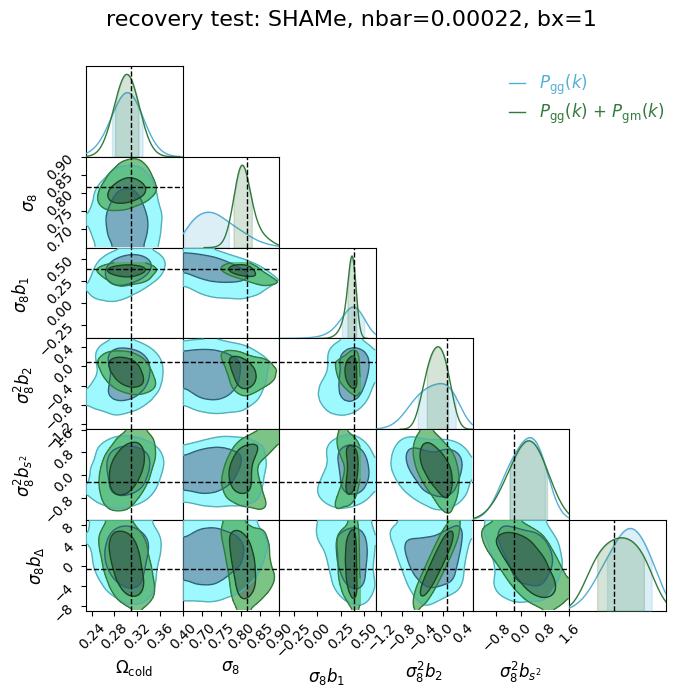

In [ ]:
idx_obs = 0
title = f'recovery test: SHAMe, nbar={tag_mock.split("nbar")[-1]}, bx={bx}'
tags_test = ['_' + data_mode_test + tag_stats_arr[i] + tag_mock for i in range(len(tag_stats_arr))]

param_names_contour = ['omega_cold', 'sigma8_cold'] + utils.biasparam_names_ordered
theta_test_show = theta_test[[i for i, name in enumerate(param_names_vary) if name in param_names_contour]]

plotter.plot_contours_inf(
    param_names_contour, idx_obs, theta_test_show,
    inf_methods, tags_inf, tags_test=tags_test,
    colors=colors, labels=labels,
    title=title, extents=extents, fontsize_legend=12,
)

fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx1_ntrain10000/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx1_ntrain10000/samples_test_shame_pk_pgm_nbar0.00022_pred.npy


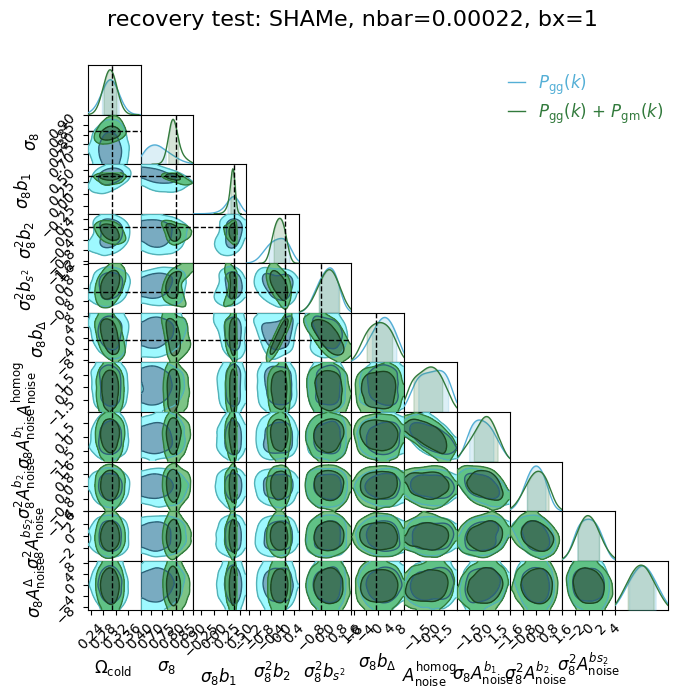

In [ ]:
idx_obs = 0
title = f'recovery test: SHAMe, nbar={tag_mock.split("nbar")[-1]}, bx={bx}'
tags_test = ['_' + data_mode_test + tag_stats_arr[i] + tag_mock for i in range(len(tag_stats_arr))]

param_names_contour = ['omega_cold', 'sigma8_cold'] + utils.biasparam_names_ordered + utils.noiseparam_names_ordered
theta_test_show = theta_test[[i for i, name in enumerate(param_names_vary) if name in param_names_contour]]

plotter.plot_contours_inf(
    param_names_contour, idx_obs, theta_test_show,
    inf_methods, tags_inf, tags_test=tags_test,
    colors=colors, labels=labels,
    title=title, extents=extents, fontsize_legend=12,
)

### bx=4

In [26]:
# SHAMe mock results: bx=1 (pk and pk+pgm)
data_mode = 'muchisimocks'
tag_params = '_p5_n10000'
tag_biasparams = '_biasnoisenest_p9_n320000'
tag_noise = '_noise_unit_p5_n10000'
bx = 4
tag_reparam = '_rp'
n_train = 10000
statistics_arr = [['pk'], ['pk', 'pgm']]
tag_stats_arr = [f'_{"_".join(statistics)}' for statistics in statistics_arr]
tag_num = f'_bx{bx}_ntrain{n_train}'
tags_inf = [f'_{data_mode}{tag_stats}{tag_params}{tag_biasparams}{tag_noise}{tag_reparam}{tag_num}' for tag_stats in tag_stats_arr]
inf_methods = ['sbi'] * len(tags_inf)
labels = [utils.get_stat_label(stat) for stat in statistics_arr]
colors = [color_pk, color_pk_pgm]
print(tags_inf)

['_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx4_ntrain10000', '_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx4_ntrain10000']


In [27]:
# load training set parameters (no Anoise)
params_df, param_dict_fixed, biasparams_df, biasparams_dict_fixed, random_ints, random_ints_bias = data_loader.load_params(tag_params, tag_biasparams)
cosmo_param_names_vary, bias_param_names_vary = [], []
if params_df is not None:
    cosmo_param_names_vary = params_df.columns.tolist()
if biasparams_df is not None:
    bias_param_names_vary = biasparams_df.columns.tolist()
    bias_param_names_vary.remove('nest_layer')
    bias_param_names_vary.remove('idx_cosmo')
param_names_vary = cosmo_param_names_vary + bias_param_names_vary

# load SHAMe mock OOD test set
data_mode_test = 'shame'
tag_mock = '_nbar0.00022'
theta_test = data_loader.load_theta_ood(
    data_mode_test, tag_mock,
    cosmo_param_names_vary=cosmo_param_names_vary,
    bias_param_names_vary=bias_param_names_vary,
)
print(theta_test)

# get bounds (updated generate_params API)
dict_bounds_cosmo = genp.get_bounds('cosmo')
dict_bounds_bias = genp.get_bounds('bias')
extents = {**dict_bounds_cosmo, **dict_bounds_bias}

print(param_names_vary)

[ 0.3089      0.81590003  0.6774      0.0486      0.9667      0.47410742
  0.12701492 -0.33881766 -0.82443643         nan         nan         nan
         nan         nan]
['omega_cold', 'sigma8_cold', 'hubble', 'omega_baryon', 'ns', 'b1', 'b2', 'bs2', 'bl', 'An_homog', 'An_b1', 'An_b2', 'An_bs2', 'An_bl']


fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx4_ntrain10000/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx4_ntrain10000/samples_test_shame_pk_pgm_nbar0.00022_pred.npy


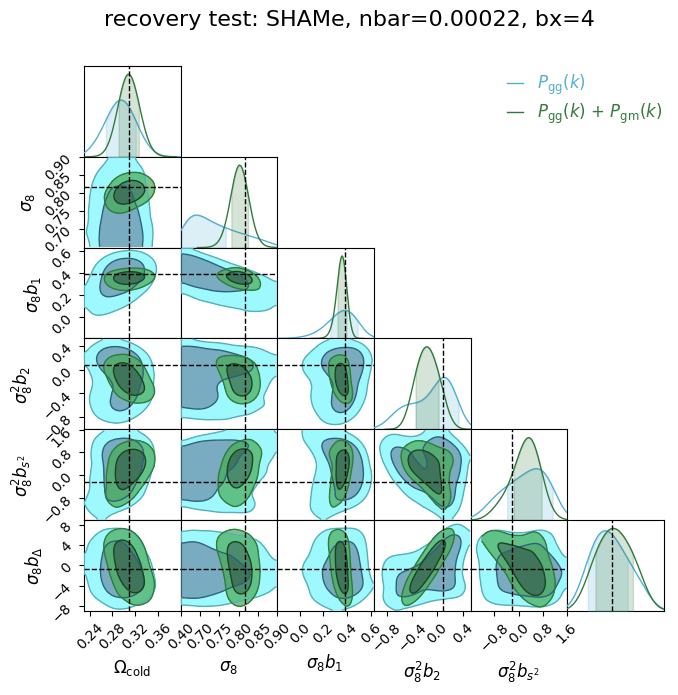

In [30]:
idx_obs = 0
title = f'recovery test: SHAMe, nbar={tag_mock.split("nbar")[-1]}, bx={bx}'
tags_test = ['_' + data_mode_test + tag_stats_arr[i] + tag_mock for i in range(len(tag_stats_arr))]

param_names_contour = ['omega_cold', 'sigma8_cold'] + utils.biasparam_names_ordered
theta_test_show = theta_test[[i for i, name in enumerate(param_names_vary) if name in param_names_contour]]

plotter.plot_contours_inf(
    param_names_contour, idx_obs, theta_test_show,
    inf_methods, tags_inf, tags_test=tags_test,
    colors=colors, labels=labels,
    title=title, extents=extents, fontsize_legend=12,
)

fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx4_ntrain10000/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = ../results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisenest_p9_n320000_noise_unit_p5_n10000_rp_bx4_ntrain10000/samples_test_shame_pk_pgm_nbar0.00022_pred.npy


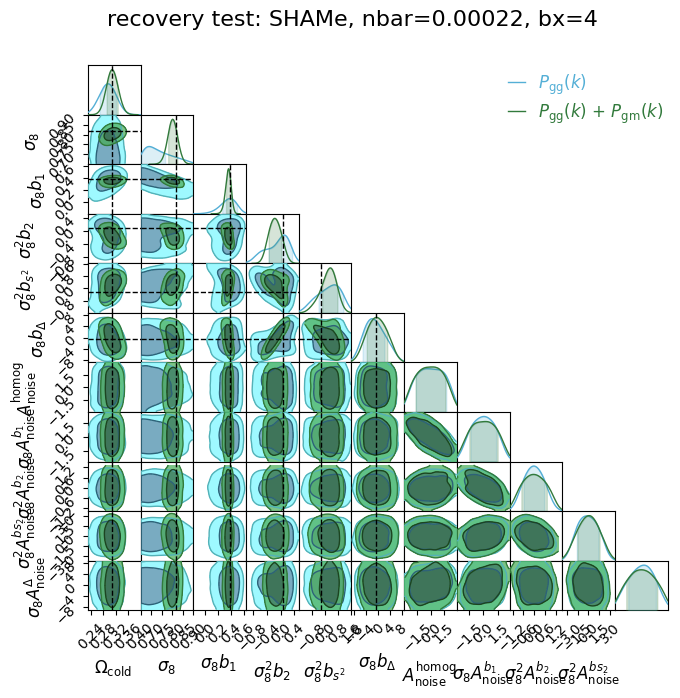

In [31]:
idx_obs = 0
title = f'recovery test: SHAMe, nbar={tag_mock.split("nbar")[-1]}, bx={bx}'
tags_test = ['_' + data_mode_test + tag_stats_arr[i] + tag_mock for i in range(len(tag_stats_arr))]

param_names_contour = ['omega_cold', 'sigma8_cold'] + utils.biasparam_names_ordered + utils.noiseparam_names_ordered
theta_test_show = theta_test[[i for i, name in enumerate(param_names_vary) if name in param_names_contour]]

plotter.plot_contours_inf(
    param_names_contour, idx_obs, theta_test_show,
    inf_methods, tags_inf, tags_test=tags_test,
    colors=colors, labels=labels,
    title=title, extents=extents, fontsize_legend=12,
)